In [36]:
import os, gdown, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download("punkt")
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saivarshith\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\saivarshith\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saivarshith\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\saivarshith\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\saivarshith\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
# globals
TWITTER_DS_NAME = "corona_tweets.csv"
BATCH_SIZE=64
dataSetDriveID = "11LWo5nagSmC72hOJM9lm2l05sdQxt4rf"

In [7]:
# function to download the dataset from the url
def download_dataset_from_url(url, file_path):
    try:
        gdown.download(url, file_path, quiet=False)
        print(f"Successfully downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading file: {e}")

def download_and_prep_dataset(FILE_ID, downloadLoc="dataSet", dataSetName=""):
    # Download the dataset
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    currentPath = os.getcwd()
    print("CWD: ", currentPath)
    dataSetPath = os.path.abspath(os.path.join(currentPath, downloadLoc + "/"))

    # create directory if not exists
    if not os.path.exists(dataSetPath):
        os.mkdir(dataSetPath)

    fileFullPath = os.path.join(dataSetPath)
    # download the dataset
    if not os.path.exists(fileFullPath):
        download_dataset_from_url(url=url, file_path=dataSetPath)

    # Load the dataset
    return fileFullPath

In [8]:
# datasetLoc = download_and_prep_dataset(FILE_ID=dataSetDriveID)
currDir = os.getcwd()
datasetLoc = os.path.join(currDir, "dataSet", TWITTER_DS_NAME)
twitterDS = pd.read_csv(datasetLoc)

In [9]:
twitterDS.head(3)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive


## Data Exploration

In [10]:
dataAnalysis = twitterDS.copy()

Sentiment         
Negative              1041
Positive               947
Neutral                619
Extremely Positive     599
Extremely Negative     592
Name: count, dtype: int64

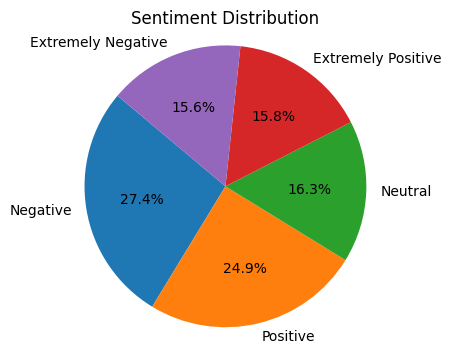

------------------------------------------------------------
The data set is slightly miss balanced. 
 Techniques like oversampling/smote doesn't work here.


2319

In [11]:
## data set distributuon

display(dataAnalysis.value_counts(subset=["Sentiment"]))

# Count the occurrences of each sentiment
sentiment_counts = twitterDS['Sentiment'].value_counts()

# Plot the pie chart
plt.figure(figsize=(4, 4))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Sentiment Distribution')
plt.axis('equal')
plt.show()

print("--" * 30)
print("The data set is slightly miss balanced. \n Techniques like oversampling/smote doesn't work here.")

del(dataAnalysis)
gc.collect()

## Data preperation 

In [12]:
## convert the category to binary
def convertTo2Categ(x):
    if x in ["Extremely Positive", "Positive"]:
        return "Positive"
    else:
        return "Negative"

## data tweet preperation by removing hyperlinks, special characters, etc.
def preprocess_tweet(tweet):
    # local variables
    wrdLemm = WordNetLemmatizer()
    tknizer = TweetTokenizer(preserve_case=False, reduce_len=False, strip_handles=True)

    # Remove hyperlinks
    tweet = re.sub(r'http\S+', '', tweet)
    
    # Remove mentions
    tweet = re.sub(r'@\w+', '', tweet)
    
    # Remove hashtags
    tweet = re.sub(r'[^A-Za-z0-9\s]', '', tweet)  # Remove special characters

    # tweet tokenization
    tokenTweet = tknizer.tokenize(tweet)

    #remove stop words
    tweet = [wrdLemm.lemmatize(word) for word in tokenTweet if word not in set(stopwords.words('english'))]
    return tweet

def sumFrequencyWord(x, vocalFreqDF):
    sumPos = 0
    sumNeg = 0
    SentimentList = ["Positive", "Negative"]

    for word in x["OriginalTweet"]:
        for sentimentType in SentimentList:
            idx = (word, sentimentType)
            if sentimentType == "Positive" and idx in vocalFreqDF.index:
                sumPos += vocalFreqDF.loc[idx]["Freq"]
            if sentimentType == "Negative" and idx in vocalFreqDF.index:
                sumNeg += vocalFreqDF.loc[idx]["Freq"]
    
    x["posFreq"] = sumPos
    x["negFreq"] = sumNeg
    return x

In [13]:
# We want to do binary classification
# We can combine Positive and Extremely Positive to one bucket
# We can combine Negative and Extremely Negative to one bucket

dataModelling = twitterDS.copy()
initialCount = dataModelling.shape[0]
print(f"# of tweets initially: {initialCount}" )
print("-"*30)

# create mask to drop Neutral tweets
mask = dataModelling["Sentiment"] == "Neutral"
dataModelling = dataModelling.loc[~mask]
finalCount = dataModelling.shape[0]

print("\n", dataModelling["Sentiment"].value_counts())
print("-"*30)
print(f"\n# of tweets after removing Neutral: {finalCount}" )
print(f"#tweets dropped: {initialCount-finalCount}")

## Combine Extreme and general to single category

# of tweets initially: 3798
------------------------------

 Sentiment
Negative              1041
Positive               947
Extremely Positive     599
Extremely Negative     592
Name: count, dtype: int64
------------------------------

# of tweets after removing Neutral: 3179
#tweets dropped: 619


In [14]:
dataModelling["Sentiment"] = dataModelling["Sentiment"].apply(convertTo2Categ)

print("DataSet after converting the data into only 2 categories")
display(dataModelling["Sentiment"].value_counts())

## we can see that the data is balanced for 2 categories

DataSet after converting the data into only 2 categories


Sentiment
Negative    1633
Positive    1546
Name: count, dtype: int64

In [15]:
dataModelling["OriginalTweet"] = dataModelling["OriginalTweet"].apply(preprocess_tweet)

In [16]:
# frequency Count for classification

# Vocab freq table 
VocalFreqDF = dataModelling.explode(column="OriginalTweet")
VocalFreqDF = VocalFreqDF.groupby(["OriginalTweet", 'Sentiment']).aggregate({"OriginalTweet": "count"})
VocalFreqDF = VocalFreqDF.rename(columns={"OriginalTweet": "Freq"})

display(VocalFreqDF.sort_values(by="Freq", ascending=False))

,,Freq
OriginalTweet,Sentiment,
covid,Negative,1301
19,Negative,1203
covid,Positive,1144
19,Positive,1046
food,Negative,694
...,...,...
03,Positive,1
03162020,Negative,1
038,Positive,1


In [21]:
dataModelling = dataModelling.apply(lambda x: sumFrequencyWord(x, VocalFreqDF), axis=1)
dataModelling["bias"] = (np.ones(dataModelling.shape[0]))

In [23]:
dataPrepred = dataModelling[["posFreq", "negFreq", "bias"]]
dataLabel = dataModelling["Sentiment"].apply(lambda x: 1 if x == "Positive" else 0)

X_train, X_test, y_train, y_test = train_test_split(dataPrepred, dataLabel, test_size=0.2, random_state=42)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (2543, 3)
X_test shape:  (636, 3)
y_train shape:  (2543,)
y_test shape:  (636,)


## Model Creation and evaluation

In [ ]:
# Logistic Regression

logisticRegr = LogisticRegression()
logisticRegr.fit(X_train, y_train)

#### Test data predictions

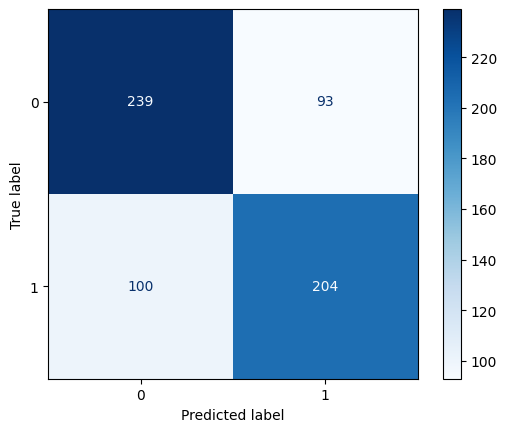

In [62]:
# Test Data Metrix
testPredictions = logisticRegr.predict(X_test)
confMatrix =confusion_matrix(y_test, testPredictions)
disp = ConfusionMatrixDisplay(confusion_matrix=confMatrix, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [63]:
print(classification_report(y_test, testPredictions))

              precision    recall  f1-score   support

           0       0.71      0.72      0.71       332
           1       0.69      0.67      0.68       304

    accuracy                           0.70       636
   macro avg       0.70      0.70      0.70       636
weighted avg       0.70      0.70      0.70       636



The model has 70% accuracy on the test data.

#### Train Data Metrics

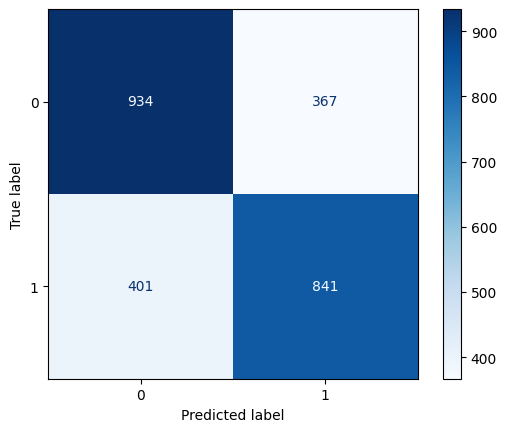

In [60]:
# Test Data Metrix
trainPredictions = logisticRegr.predict(X_train)
cm = confusion_matrix(y_train, trainPredictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [61]:
print(classification_report(y_train, trainPredictions))

              precision    recall  f1-score   support

           0       0.70      0.72      0.71      1301
           1       0.70      0.68      0.69      1242

    accuracy                           0.70      2543
   macro avg       0.70      0.70      0.70      2543
weighted avg       0.70      0.70      0.70      2543



Training and Test Scores are almost same. So, our model is not overfitting.
- Accuracy of the model is 70%
- The model is doing a decent job in predicting the sentiment associated with the tweets. 